In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH
from pathlib import Path

import re
import numpy as np
import pynapple as nap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DECODED_DATA_PATH = Path("D:\\common_datasets\\nrem_sc")
UNITS = ['83b', '85b', '116b', '119b']
UNIT = UNITS[1]

sleep_states = nap.load_file(PROCESSED_DATA_PATH / UNIT / "sleep.npz")
session = nap.load_file(PROCESSED_DATA_PATH / UNIT / "sessions_labeled.npz")

(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

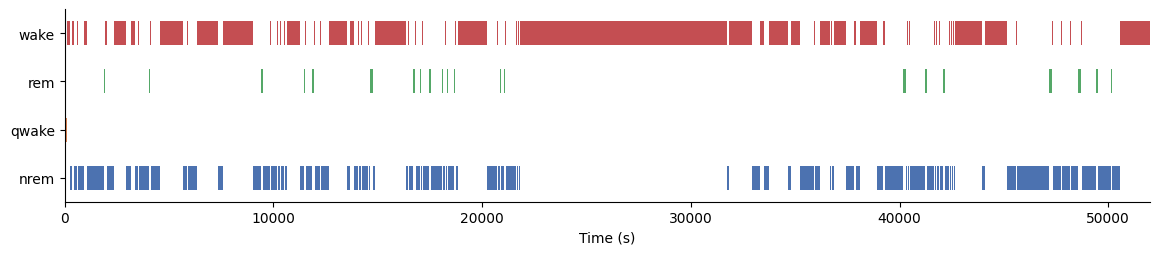

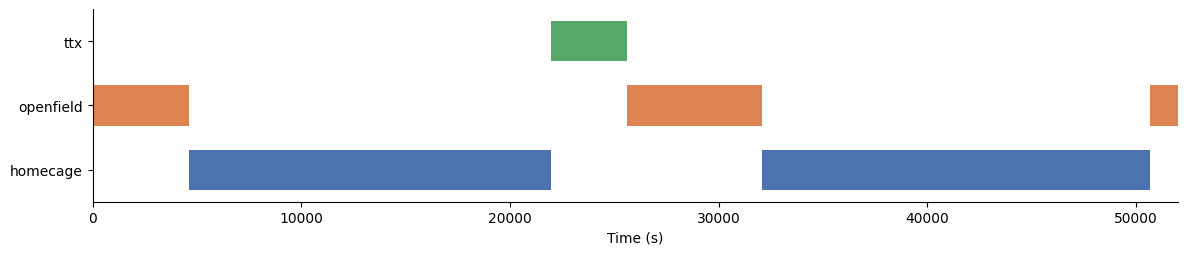

In [2]:
from nrem_sc.utils import plot_intervals

plot_intervals(sleep_states, column='state')
plot_intervals(session, column='label')

### Detect sweeps

In [3]:
def extract_sweeps(tdf, label='continuous', min_gap_ms=50):
    epochs = tdf[tdf['state'] == label].find_support(min_gap=min_gap_ms, time_units='ms')
    
    if len(epochs) == 0:
        return pd.DataFrame()

    # Single restrict call for ALL epochs
    all_data = tdf.restrict(epochs)
    pos = all_data['position'].values
    times = all_data.times('s')

    # Assign each sample to its epoch via searchsorted
    starts = epochs['start']
    epoch_idx = np.searchsorted(starts, times, side='right') - 1

    # Split arrays at epoch boundaries
    split_at = np.flatnonzero(np.diff(epoch_idx)) + 1
    pos_chunks = np.split(pos, split_at)
    time_chunks = np.split(times, split_at)

    durations = np.empty(len(pos_chunks))
    net_disp  = np.empty(len(pos_chunks))
    path_len  = np.empty(len(pos_chunks))
    integral  = np.empty(len(pos_chunks))
    n_samples = np.empty(len(pos_chunks), dtype=int)

    for i, (p, t) in enumerate(zip(pos_chunks, time_chunks)):
        uw = np.unwrap(p, period=360)
        durations[i] = t[-1] - t[0]
        net_disp[i]  = np.diff(uw).sum()
        path_len[i]  = np.abs(np.diff(uw)).sum()
        integral[i]  = np.sum(p-p[0])
        n_samples[i] = len(p)

    mask = n_samples >= 2
    return pd.DataFrame({
        'duration': durations[mask],
        'net_displacement': net_disp[mask],
        'path_length': path_len[mask],
        'integral': integral[mask],
        'n_samples': n_samples[mask],
    })

In [4]:
tdf = nap.load_file(DECODED_DATA_PATH / UNIT / "states_combined.npz").as_dataframe()
tdf['position'] = nap.load_file(DECODED_DATA_PATH / UNIT / "position_combined.npz").as_series()
tdf['condition'] = 'pre_ttx'
post_idx = tdf.index > session[session['label'] == 'ttx']['start'].item()
tdf.loc[post_idx, 'condition'] = 'post_ttx'
tdf

,continuous,fragmented,stationary,position,condition
4616.85655,0.309476,0.102560,0.587964,79.498991,pre_ttx
4616.85755,0.309289,0.098536,0.592175,79.498991,pre_ttx
4616.85855,0.309296,0.093882,0.596823,79.498991,pre_ttx
4616.85955,0.309520,0.088518,0.601963,79.498991,pre_ttx
4616.86055,0.309992,0.082352,0.607656,79.498991,pre_ttx
...,...,...,...,...,...
50682.41570,0.387051,0.083018,0.529931,0.499994,post_ttx
50682.41670,0.386750,0.085527,0.527724,0.499994,post_ttx
50682.41770,0.386340,0.088280,0.525380,0.499994,post_ttx
50682.41870,0.385815,0.091292,0.522893,0.499994,post_ttx


In [5]:
threshold = 0.55
dfs = []
for condition in ['pre_ttx', 'post_ttx']:
    data = tdf[tdf['condition'] == condition].copy(deep=True)

    # Determine the state if p>threshold, otherwise 'mixture'
    labels = data[['continuous', 'fragmented', 'stationary']]
    data['state'] = np.where(labels.max(axis=1) > threshold, labels.idxmax(axis=1), 'mixture')

    # Assign sleep state
    data['sleep_state'] = 'unknown'   
    for ep in sleep_states:
        start, end = ep['start'].item(), ep['end'].item()
        if start > data.index[-1]:
            break
        valid = (data.index > start) & (data.index < end)
        data.loc[valid, 'sleep_state'] = ep['state'].item()
    
    # Extract sweeps
    data = nap.TsdFrame(data)
    sweeps = extract_sweeps(data[data['sleep_state'] == 'nrem'], label='continuous', min_gap_ms=50)
    sweeps['condition'] = condition
    sweeps['sleep_state'] = 'nrem'
    dfs.append(sweeps)

sweeps = pd.concat(dfs)

# Partition sweeps into quartiles based on duration
sweeps['quartile'] = pd.qcut(sweeps['duration'], 4, labels=False)
# Compute velocity
sweeps['velocity'] = sweeps['net_displacement']/sweeps['duration']

# Stats
stats = sweeps[sweeps['sleep_state'] == 'nrem']['duration'].describe()
stats

count    10951.000000
mean         0.189197
std          0.143990
min          0.001000
25%          0.083000
50%          0.161000
75%          0.255000
max          1.210000
Name: duration, dtype: float64

### Visualize

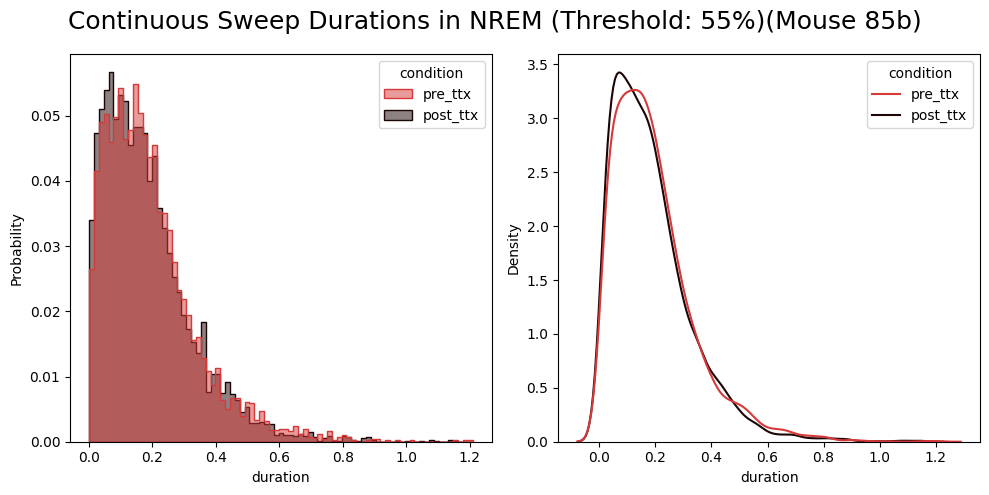

In [7]:
from nrem_sc.constants import INTERIM_DATA_PATH

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
hist_kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)
fig.suptitle(f'Continuous Sweep Durations in NREM (Threshold: {threshold*100:.0f}%)(Mouse {UNIT})', fontsize=18)

axes[0] = sns.histplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', **hist_kwargs, ax=axes[0])
# axes[0].set_xlim(-.1, 1.75)

axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'], x='duration', hue='condition', common_norm=False, palette=palette, ax=axes[1])
# axes[1].set_xlim(-.1, 1.75)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'nrem_sweep_durations.pdf', format='pdf', dpi=1200)

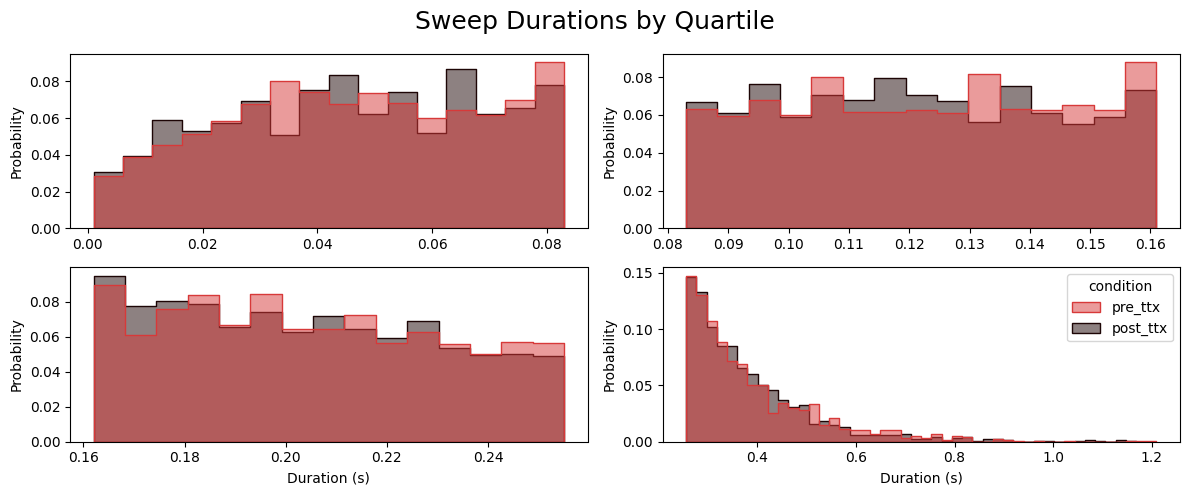

In [8]:
palette = ["#d73939", "#1d0505ff"]
kwargs = dict(element='step', stat='probability', common_norm=False, fill=True, alpha=0.5, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle('Sweep Durations by Quartile', fontsize=18)

axes[0, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 0], x='duration', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_xlabel('')

axes[0, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 1], x='duration', hue='condition', **kwargs, ax=axes[0, 1], legend=False)
axes[0, 1].set_xlabel('')

axes[1, 0] = sns.histplot(data=sweeps[sweeps['quartile'] == 2], x='duration', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_xlabel('Duration (s)')

axes[1, 1] = sns.histplot(data=sweeps[sweeps['quartile'] == 3], x='duration', hue='condition', **kwargs, ax=axes[1, 1], legend=True)
axes[1, 1].set_xlabel('Duration (s)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_durations_quartiles.pdf', format='pdf', dpi=1200)

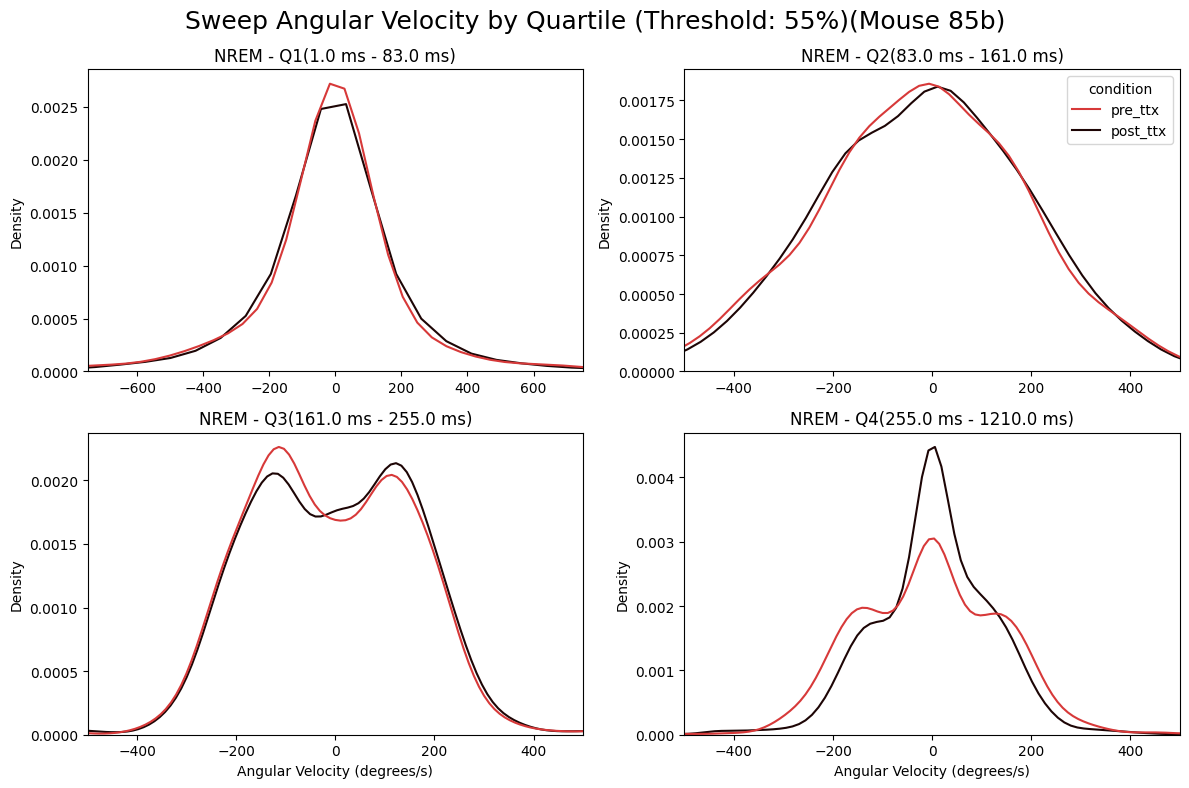

In [10]:

kwargs = dict(common_norm=False, palette=palette)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Sweep Angular Velocity by Quartile (Threshold: {threshold*100:.0f}%)(Mouse {UNIT})', fontsize=18)

axes[0, 0] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 0], x='velocity', hue='condition', **kwargs, ax=axes[0, 0], legend=False)
axes[0, 0].set_title(f'NREM - Q1({stats["min"]*1000:.1f} ms - {stats["25%"]*1000:.1f} ms)')
axes[0, 0].set_xlabel('')
axes[0, 0].set_xlim(-750, 750)

axes[0, 1] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 1], x='velocity', hue='condition', **kwargs, ax=axes[0, 1])
axes[0, 1].set_title(f'NREM - Q2({stats["25%"]*1000:.1f} ms - {stats["50%"]*1000:.1f} ms)')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xlim(-500, 500)

axes[1, 0] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 2], x='velocity', hue='condition', **kwargs, ax=axes[1, 0], legend=False)
axes[1, 0].set_title(f'NREM - Q3({stats["50%"]*1000:.1f} ms - {stats["75%"]*1000:.1f} ms)')
axes[1, 0].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 0].set_xlim(-500, 500)

axes[1, 1] = sns.kdeplot(data=sweeps[sweeps['quartile'] == 3], x='velocity', hue='condition', **kwargs, ax=axes[1, 1], legend=False)
axes[1, 1].set_title(f'NREM - Q4({stats["75%"]*1000:.1f} ms - {stats["max"]*1000:.1f} ms)')
axes[1, 1].set_xlabel('Angular Velocity (degrees/s)')
axes[1, 1].set_xlim(-500, 500)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_quartiles_kde.pdf', format='pdf', dpi=1200)

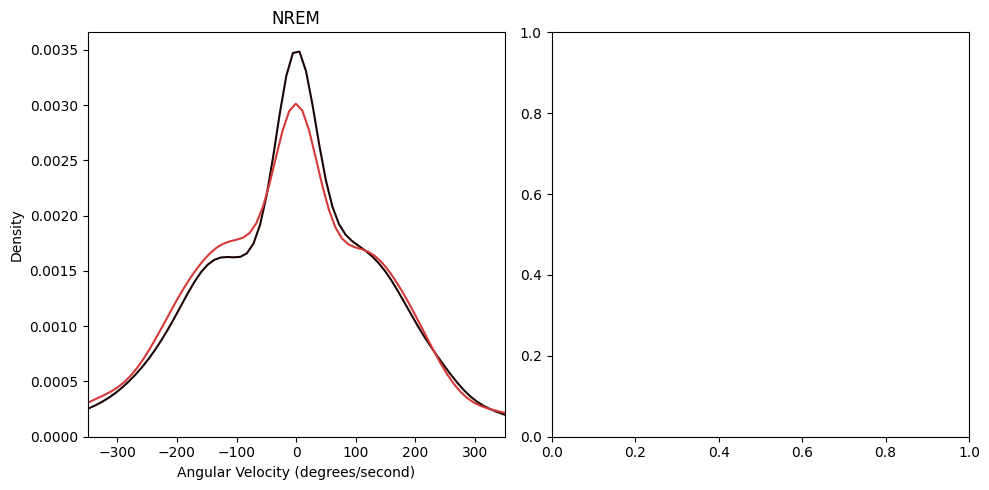

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]
kwargs = dict(common_norm=False, palette=palette)

mask = sweeps[sweeps['sleep_state'] == 'nrem']['velocity'].abs() < 1000
axes[0] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'nrem'][mask]), x='velocity', hue='condition', **kwargs, ax=axes[0], legend=False)
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Velocity (degrees/second)')
axes[0].set_xlim(-350, 350)

# axes[1] = sns.kdeplot(data=(sweeps[sweeps['sleep_state'] == 'rem']), x='velocity', hue='condition', **kwargs, ax=axes[1], legend=True)
# axes[1].set_title('REM')
# axes[1].set_xlabel('Angular Velocity (degrees/second)')
# axes[1].set_xlim(-350, 350)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_velocity_kde.pdf', format='pdf', dpi=1200)

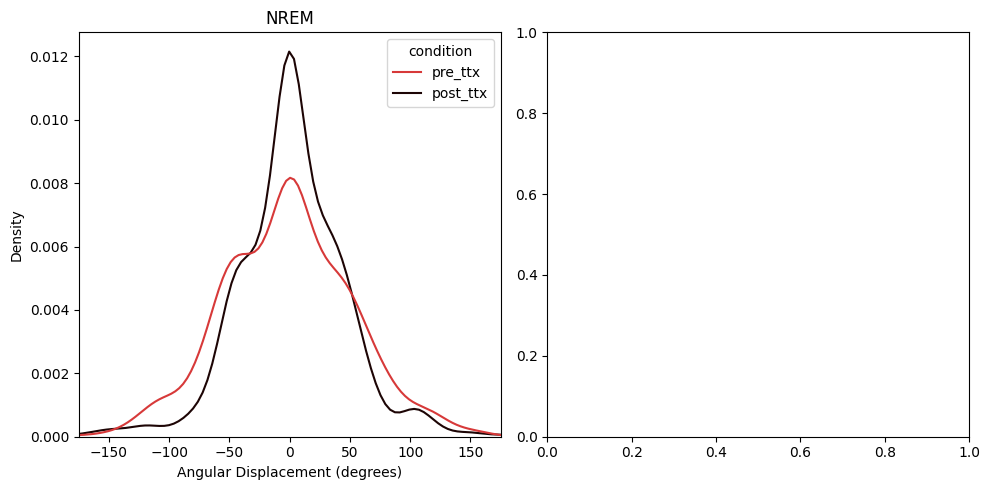

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

palette = ["#d73939", "#1d0505ff"]

kwargs = dict(common_norm=False, cumulative=False, fill=False, alpha=1, palette=palette)


mask = sweeps[sweeps['sleep_state'] == 'nrem']['duration'].abs() > 0.25
axes[0] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'nrem'][mask], x='net_displacement', hue='condition', **kwargs, ax=axes[0])
axes[0].set_title('NREM')
axes[0].set_xlabel('Angular Displacement (degrees)')
axes[0].set_xlim(-175, 175)

# axes[1] = sns.kdeplot(data=sweeps[sweeps['sleep_state'] == 'rem'], x='net_displacement', hue='condition', **kwargs, ax=axes[1])
# axes[1].set_title('REM')
# axes[1].set_xlabel('Angular Displacement (degrees)')

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_angular_displacement_kde.pdf', format='pdf', dpi=1200)

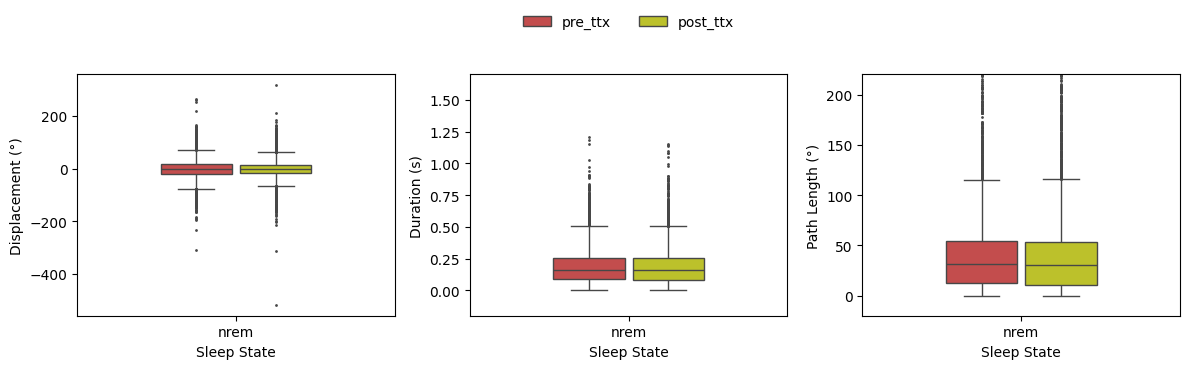

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
palette = ["#d73939", "#d3da12ff"]
box_kwargs = dict(fliersize=1, width=0.5, palette=palette, gap=0.1)

# fig.suptitle('Sweep Metrics by Sleep State', fontsize=18)

axes[0] = sns.boxplot(data=sweeps, x='sleep_state', y='net_displacement', hue='condition', **box_kwargs, ax=axes[0], legend=False)
# axes[0].set_ylim(-150, 150)
axes[0].set_ylabel('Displacement (°)')
axes[0].set_xlabel('Sleep State')

axes[1] = sns.boxplot(data=sweeps, x='sleep_state', y='duration', hue='condition', **box_kwargs, ax=axes[1])
axes[1].set_ylabel('Duration (s)')
axes[1].set_xlabel('Sleep State')
axes[1].set_ylim(-0.2, 1.7)

sns.move_legend(axes[1], "upper center", bbox_to_anchor=(0.5, 1.3),  ncol=3, title=None, frameon=False)

axes[2] = sns.boxplot(data=sweeps, x='sleep_state', y='path_length', hue='condition', **box_kwargs, ax=axes[2], legend=False)
axes[2].set_ylabel('Path Length (°)')
axes[2].set_xlabel('Sleep State')
axes[2].set_ylim(-20, 220)

fig.tight_layout()
# fig.savefig(INTERIM_DATA_PATH / unit_id / 'figures' / 'sweep_boxplots.pdf', format='pdf', dpi=1200)